<a href="https://colab.research.google.com/github/raja-kumar-jha/pytorch-deep-learning-journey/blob/main/notebooks/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

Let's explore an example of PyTorch ene-to-end workflow

**what were covering :**

1. data (prepare and load)
2. build model
3. fitting the model to data (training)
4. making predictions and evaluting a model (inference)
5. putting it all together

In [1]:
import torch
from torch import nn # nn contains all the PyTorch building blocks for nural network
import matplotlib.pyplot as plt

# check PyTorch Version
print(torch.__version__)

2.11.0+cpu


## 1. Data preparing and loading

Data can be anything.. in machine learning.

* Excel/Google sheet
* Image of any kind
* Video(youtube has a lots of data..)
* Audio like songs or podcasts and many more things
* DNA
* Text

Machine learing is a game of two parts:
1. Get data into numerical fashion
2. Build model to learn patterns in that numerical data

In [2]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets

In [4]:
# Create a train/test split
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  """
  Plot training data , test data and compares predictions.
  """
  plt.figure(figsize=(6, 5))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # plot the predictions if they exist
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")
  # show the legend
  plt.legend(prop={"size":12});

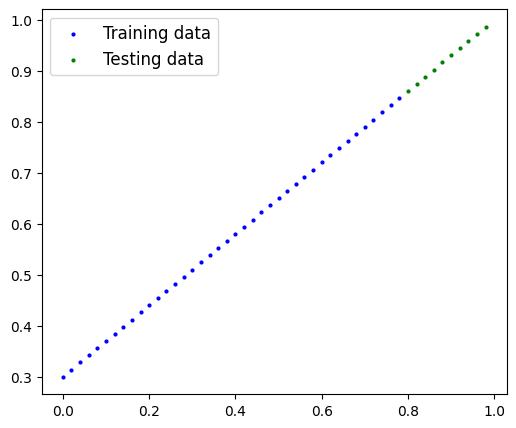

In [6]:
plot_predictions();

## 2. Building model
My first PyTorch model!

What our model does:
* Start with random values(weight & bias)
* Look at the training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithm:
1. Gradient descent
2. Backpropagation

In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Initialize model parameter
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True, dtype=torch.float))

  # Forword method to define the computation in the model
  def forward(self, x:torch.Tensor) -> torch.Tensor: #<- "x" is the input data
    return self.weights * x + bias # this is the linear regression formula


### PyTorch model building essentials

* torch.nn - contains all of the buildings for comutational graphs(a nural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our mmodel try and learn, often a PyTorch layer from torch.nn will set these for use
* torch.nn.Module - The base class for all nural network modules, if we subclass it, we should overwrite forword()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient decent
* def forword() - all nn.Model subclass require us to overwrite forword(), this method defines what happens in forword() comutation

### checking the contents of the Pytorch model

Now we've created a model, let's see what's inside..

So we can check our model parammeters or what's inside our model using .parameters().

In [8]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)

Model_0 = LinearRegressionModel()

# check out the parameter
list(Model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List named paramers
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [10]:
# Make predictions with model
with torch.inference_mode():
  y_preds = Model_0(X_test)

y_preds

tensor([[0.5694],
        [0.5761],
        [0.5828],
        [0.5896],
        [0.5963],
        [0.6030],
        [0.6098],
        [0.6165],
        [0.6232],
        [0.6300]])

In [11]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

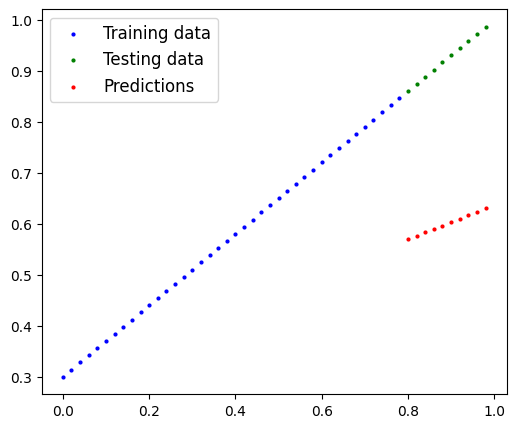

In [12]:
plot_predictions(predictions=y_preds)